In [1]:
import xgi
import numpy as np
from tqdm import tqdm
import pickle
from multiprocess import Pool
from had_model import HAD_model
import matplotlib.pyplot as plt

# 1) SocioPatterns datasets

In [5]:
tag = 'SFHH'
with open(f'../data/SocioPatterns/aggr_15min_cliques_thr1_{tag}.json') as file: 
            data = json.load(file)
H = xgi.from_hyperedge_list(data)
# relabel and remove eventual multiple edges
H.cleanup(isolates=True, singletons=True, connected=False)

N = len(H.nodes)
print(H, '\nHyperedge sizes:', xgi.unique_edge_sizes(H), '\nConnected:',  xgi.is_connected(H))

Unnamed Hypergraph with 403 nodes and 6398 hyperedges 
Hyperedge sizes: [2, 3, 4, 5, 6, 7, 8, 9, 10] 
Connected: True


## 1.1) Results as a function of $\epsilon$

- number of connected components
- size of the largest connected component
- size of the second largest connected component
- number of hyperedges
- average hyperedge size
- max hyperedge size

Results averaged over 20 realizations of the model.

In [9]:
epsilons = np.linspace(0., 0.6, num=25)[1:]
cond = 'max_min'   # condition for agreement
iterations = 20    # number of iterations for each epsilon
    
ncc = dict()
scc1 = dict()
scc2 = dict()
nhe = dict()
s_avg = dict()
s_max = dict()

# All below quantities are computed at the steady state, as a function of epsilon, averaged over 'iterations'
ncc = []      # number of connected components
scc1 = []     # size of the largest connected component
scc2 = []     # size of the second largest connected component
nhe = []      # number of hyperedges
s_avg = []    # average hyperedge size
s_max = []    # max hyperedge size
              
for eps in tqdm(epsilons):

    ncc_it = []
    scc1_it, scc2_it = [], []
    nhe_it = []
    s_avg_it, s_max_it = [], []
    
    for it in range(iterations):
        
        groups_0 = H.edges.members()        
        Model = HAD_model(eps, groups_0)
        results = Model.simulate(condition=cond)
        opinions = results['opinions']
        groups = results['groups']
        
        # number of connected components and size of the two largest
        hedges = groups[-1]
        h = xgi.Hypergraph(hedges)
        # list of connected components
        cc = [j for j in xgi.connected_components(h)]
        ncc_it.append( len(cc) )                    
        scc = set([len(i) for i in cc])
        scc1_it.append( max(scc) / N )
        scc.remove(max(scc))
        if scc:
            scc2_it.append( max(scc) / N )
        else:
            scc2_it.append(0)

        # relative number of hyperedges
        nhe_it.append( len(groups[-1]) / len(groups_0) )
        
        # relative avg and std of hyperedge sizes
        sizes_end_it = [len(e) for e in groups[-1]]
        s_avg_it.append( np.mean(sizes_end_it) )
        s_max_it.append( np.max(sizes_end_it) )
        
    ncc.append(np.mean(ncc_it))
    scc1.append(np.mean(scc1_it))
    scc2.append(np.mean(scc2_it))
    nhe.append(np.mean(nhe_it))
    s_avg.append(np.mean(s_avg_it))
    s_max.append(np.mean(s_max_it))

results = {
    'epsilons': epsilons,
    'ncc': ncc,
    'scc1': scc1,
    'scc2': scc2,
    'nhe': nhe,
    's_avg': s_avg,
    's_max': s_max
}

# save results
with open(f'../results/SP_{tag}_{cond}.pkl', 'wb') as fp:
        pickle.dump(results, fp)

100%|███████████████████████████████████████████| 24/24 [20:09<00:00, 50.42s/it]


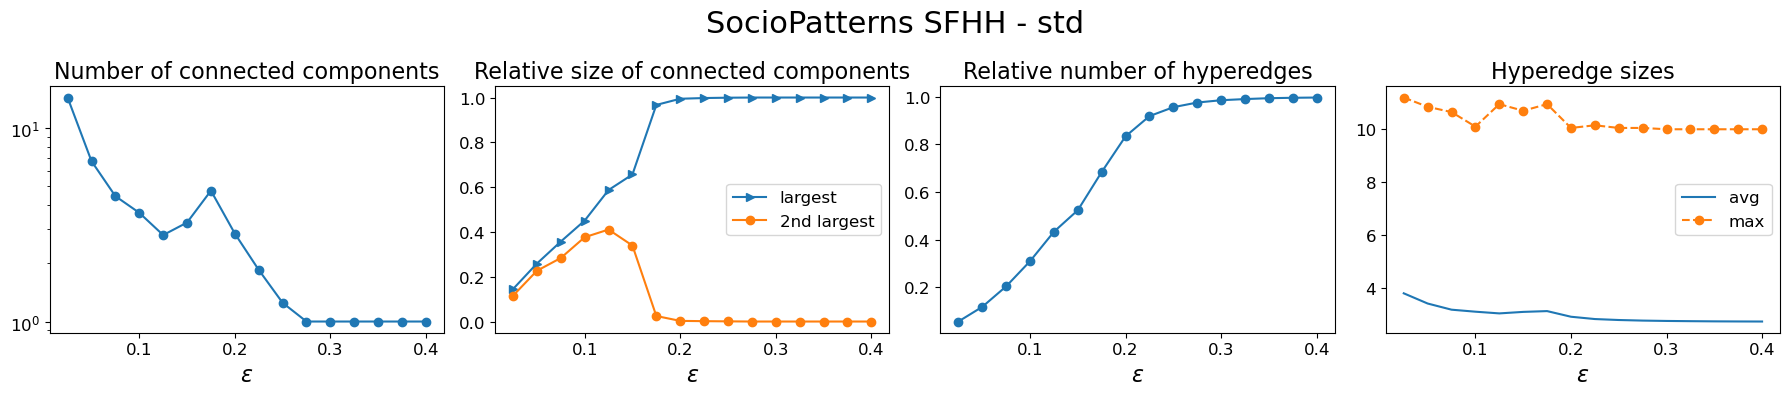

In [5]:
tag = 'SFHH'
cond = 'std'
with open(f'../results/SP_{tag}_{cond}.pkl', 'rb') as f:
    res = pickle.load(f)

epsilons = res['epsilons']
ncc = res['ncc']
scc1 = res['scc1']
scc2 = res['scc2']
nhe = res['nhe']
s_avg = res['s_avg']
s_max = res['s_max']

lbls = ['largest', '2nd largest', 'avg', 'max']
ttl_size = 16
lgd_size = 12
ncols = 4

fig, axs = plt.subplots(1,ncols, figsize=(18,4))

axs[0].plot(epsilons, ncc, marker='o')
#axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_title('Number of connected components', fontsize=ttl_size)

axs[1].plot(epsilons, scc1, linestyle='-', marker='>', label=lbls[0])
axs[1].plot(epsilons, scc2, linestyle='-', marker='o', label=lbls[1])
axs[1].legend(fontsize=lgd_size)
axs[1].set_title('Relative size of connected components', fontsize=ttl_size)
    
axs[2].plot(epsilons, nhe, marker='o')
axs[2].set_title('Relative number of hyperedges', fontsize=ttl_size)

axs[3].plot(epsilons, s_avg, label=lbls[2])
axs[3].plot(epsilons, s_max, label=lbls[3], linestyle='--', marker='o')
axs[3].legend(fontsize=lgd_size)
axs[3].set_title('Hyperedge sizes', fontsize=ttl_size)

# set xlabel tick fontsize in all subplots
for j in range(ncols):
    axs[j].tick_params(labelsize=12)
    axs[j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)

plt.suptitle(f'SocioPatterns SFHH - {cond}', fontsize=int(ttl_size*1.4))

plt.tight_layout()
plt.savefig(f'../figures/SP_{tag}_{cond}.jpg')
plt.show()

## 1.2) Various distributions for $\epsilon=0.1$

- distribution of sizes of connected components
- distribution of sizes of hypredges
- distribution of hyperedgrees

Results averaged over 100 iterations.

In [11]:
epsilon = 0.1
cond = 'max_min'   # condition for agreement
iterations = 100    # number of iterations

counts_cc = dict()
counts_he = dict()
counts_hd = dict()

for it in tqdm(range(iterations)):

    groups_0 = H.edges.members()    
    Model = HAD_model(epsilon, groups_0)
    results = Model.simulate(condition=cond)
    groups = results['groups']
    # hyperedges at the end of the simulation
    hedges = groups[-1]
    h = xgi.Hypergraph(hedges)
    
    # sizes of connected components
    scc = [len(i) for i in xgi.connected_components(h)]
    for s in sorted(scc):
        if s in counts_cc.keys():
            counts_cc[s]+=1
        else:
            counts_cc[s]=1

    # sizes of hyperedges
    she = [len(i) for i in h.edges.members()]
    for s in sorted(she):
        if s in counts_he.keys():
            counts_he[s]+=1
        else:
            counts_he[s]=1

    # hyperdegrees
    hds = h.nodes.degree.aslist()
    for deg in sorted(hds):
        if deg in counts_hd.keys():
            counts_hd[deg]+=1
        else:
            counts_hd[deg]=1
    
sizes_cc = {s: c/iterations for s,c in counts_cc.items()}
sizes_he = {s: c/iterations for s,c in counts_he.items()}
sizes_hd = {d: c/iterations for d,c in counts_hd.items()}

results = {
    'epsilon': epsilon,
    'n_iterations': iterations,
    'sizes_cc': sizes_cc,
    'sizes_he': sizes_he,
    'sizes_hd': sizes_hd
    }

# save results
with open(f'../results/SP_{tag}_{cond}_distributions_eps_{epsilon}.pkl', 'wb') as fp:
        pickle.dump(results, fp)

100%|█████████████████████████████████████████| 100/100 [05:05<00:00,  3.05s/it]


<k> = 9.992555831265511


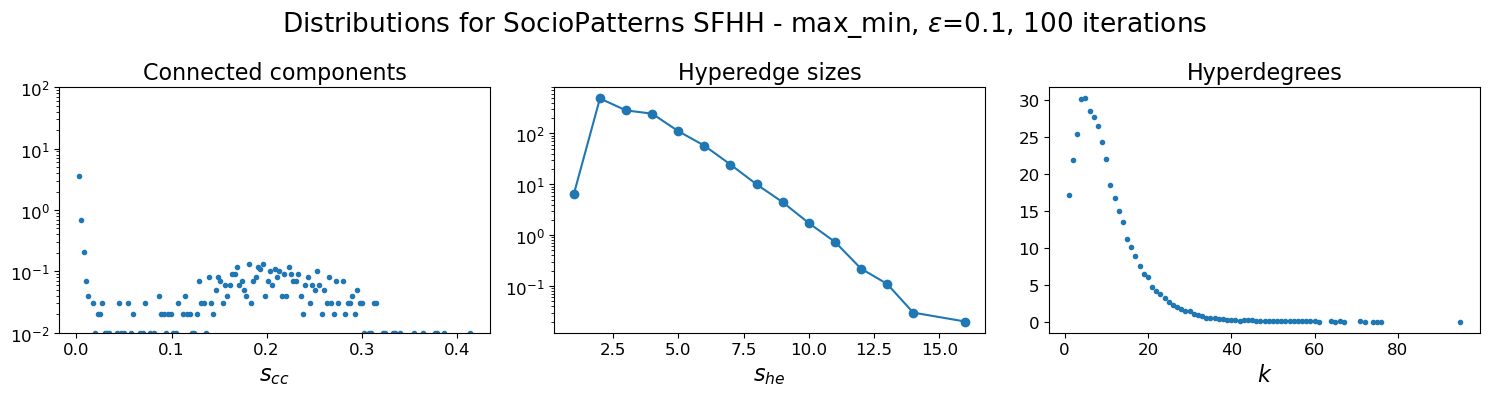

In [25]:
tag = 'SFHH'
cond = 'max_min'
epsilon = 0.1
with open(f'../results/SP_{tag}_{cond}_distributions_eps_{epsilon}.pkl', 'rb') as f:
    results = pickle.load(f)

sizes_cc = results['sizes_cc']
sizes_he = results['sizes_he']
sizes_hd = results['sizes_hd']
n_iter = results['n_iterations']

ncol = 3
fig, axs = plt.subplots(1, ncol, figsize=(15, 4))
ttl_size = 16
lgd_size = 12

x0 = [j/N for j in sorted(sizes_cc.keys())]
y0 = [sizes_cc[j] for j in sorted(sizes_cc.keys())]
axs[0].plot(x0, y0, marker='o', markersize=3, linewidth=0)
axs[0].set_yscale('log')
axs[0].set_ylim([1/n_iter, n_iter])
axs[0].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
axs[0].set_title('Connected components', rotation=0, fontsize=ttl_size)

x1 = sorted(sizes_he.keys())
y1 = [sizes_he[x] for x in x1]
axs[1].plot(x1, y1, marker='o')
axs[1].set_yscale('log')
axs[1].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
axs[1].set_title('Hyperedge sizes', rotation=0, fontsize=ttl_size)

x2 = sorted(sizes_hd.keys())
y2 = [sizes_hd[x] for x in x2]
axs[2].plot(x2, y2, marker='o', markersize=3, linewidth=0)
axs[2].set_xlabel(r'$k$', fontsize=ttl_size)
axs[2].set_title('Hyperdegrees', rotation=0, fontsize=ttl_size)

# print avg hyperdegree
hd_avg = np.dot(x2, y2) / sum(y2)
print(f'<k> = {hd_avg}')

# set tick fontsize in all subplots
for j in range(ncol):
    axs[j].tick_params(labelsize=12)
    

plt.suptitle(fr'Distributions for SocioPatterns SFHH - {cond}, $\epsilon$={epsilon}, {n_iter} iterations',
             fontsize=int(ttl_size*1.2))

plt.tight_layout()
plt.savefig(f'../figures/SP_{tag}_{cond}_distributions_eps_{epsilon}.jpg')

plt.show()

## Initial hyperdegree distribution of the dataset

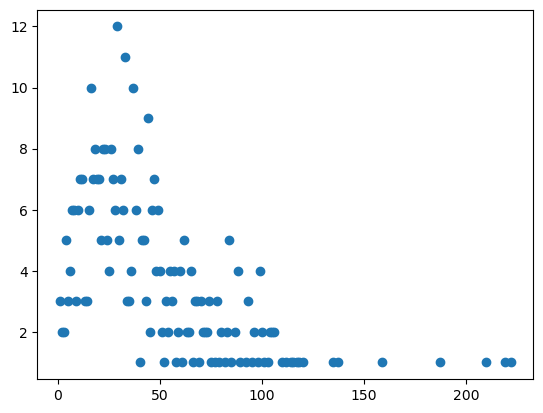

<k> = 43.21339950372209


In [17]:
# hyperdegrees
counts_hd = dict()
hds = H.nodes.degree.aslist()
for deg in sorted(hds):
    if deg in counts_hd.keys():
        counts_hd[deg]+=1
    else:
        counts_hd[deg]=1

x = sorted(counts_hd.keys())
y = [counts_hd[i] for i in x]

plt.plot(x,y, marker='o', lw=0)
plt.show()

# print avg hyperdegree
hd_avg = np.dot(x, y) / sum(y)
print(f'<k> = {hd_avg}')